# Fraud Detection - EDA
- Statistical overview
- Target distribution
- Transaction type vs. fraud
- Transaction amount analysis
- Correlation heatmap

In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load cleaned data
data = pd.read_csv("cleaned_fraud_data.csv")
data.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,181.0,0.0,0.0,0.0,1
1,1,CASH_OUT,181.0,181.0,0.0,21182.0,0.0,1
2,1,TRANSFER,2806.0,2806.0,0.0,0.0,0.0,1
3,1,CASH_OUT,2806.0,2806.0,0.0,26202.0,0.0,1
4,1,TRANSFER,20128.0,20128.0,0.0,0.0,0.0,1


In [4]:
# Back-up

df = data.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  str    
 2   amount          11142 non-null  float64
 3   oldbalanceOrg   11142 non-null  float64
 4   newbalanceOrig  11142 non-null  float64
 5   oldbalanceDest  11142 non-null  float64
 6   newbalanceDest  11142 non-null  float64
 7   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), str(1)
memory usage: 775.3 KB


In [5]:
# Target split for reference during EDA

X = df.drop(columns="isFraud")
y = df["isFraud"]

cat_columns = X.select_dtypes(include="str").columns.to_list()
num_columns = X.select_dtypes(include="number").columns.to_list()

print("Categorical columns:\n", cat_columns)
print("\nNumerical columns:\n", num_columns)

Categorical columns:
 ['type']

Numerical columns:
 ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']


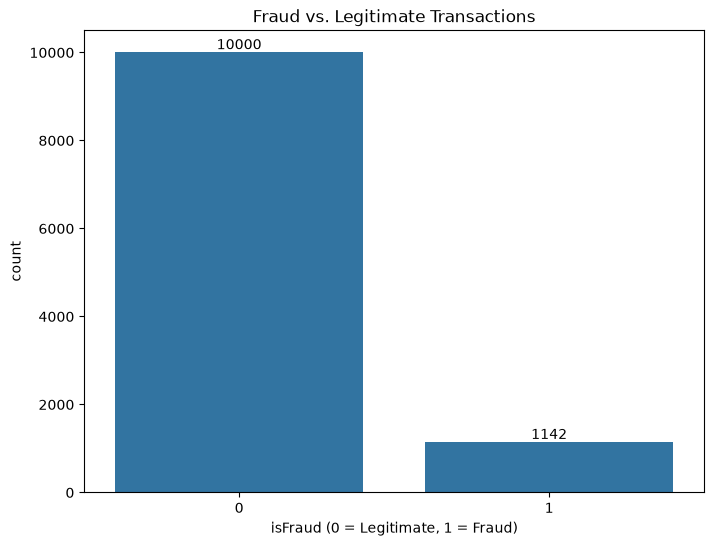

In [6]:
# Target distribution

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x="isFraud")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Fraud vs. Legitimate Transactions")
plt.xlabel("isFraud (0 = Legitimate, 1 = Fraud)")
plt.show()

### Transaction Type vs. Fraud

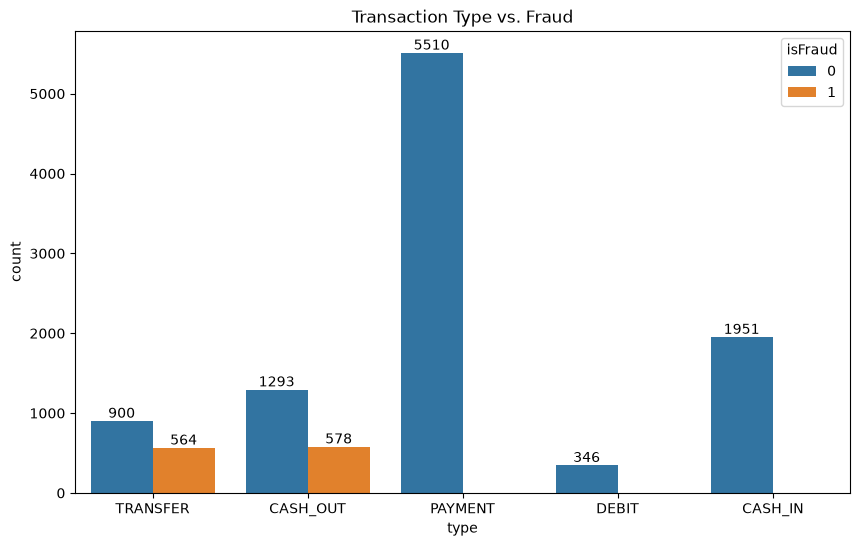

In [7]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x="type", hue="isFraud")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Transaction Type vs. Fraud")
plt.show()

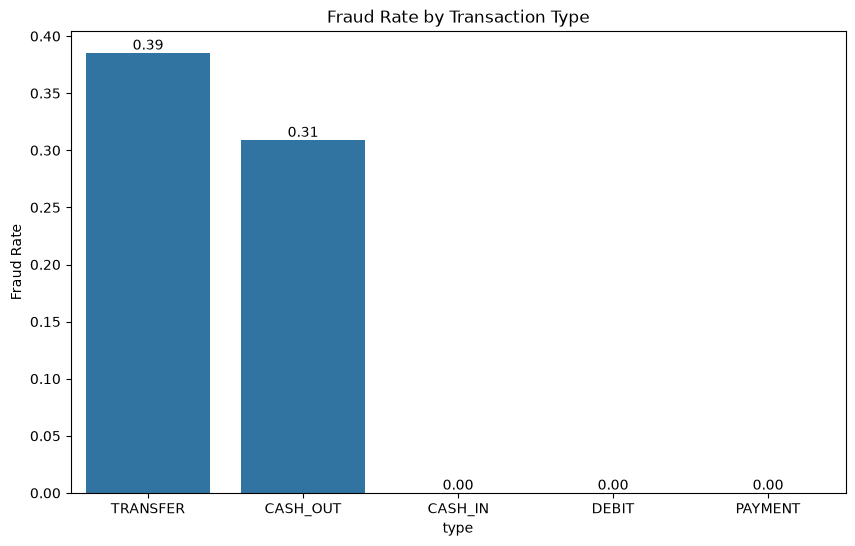

In [9]:
# Fraud rate by Transaction type

fraud_rate_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=fraud_rate_by_type.index, y=fraud_rate_by_type.values)
ax.bar_label(ax.containers[0], fmt="%.2f")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Transaction Type")
plt.show()

### Transaction amount analysis

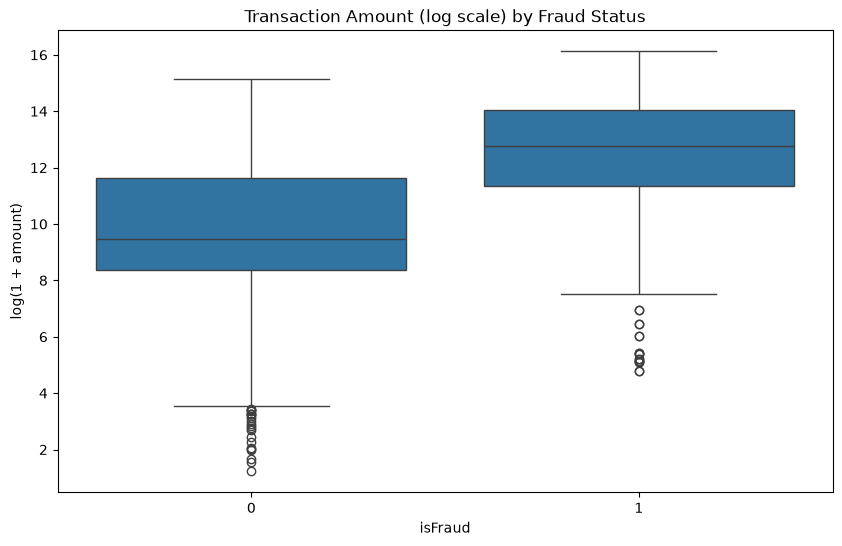

In [10]:
# Transaction amount analysis

df["log_amount"] = np.log1p(df["amount"])
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="isFraud", y="log_amount")
plt.title("Transaction Amount (log scale) by Fraud Status")
plt.xlabel("isFraud")
plt.ylabel("log(1 + amount)")
plt.show()

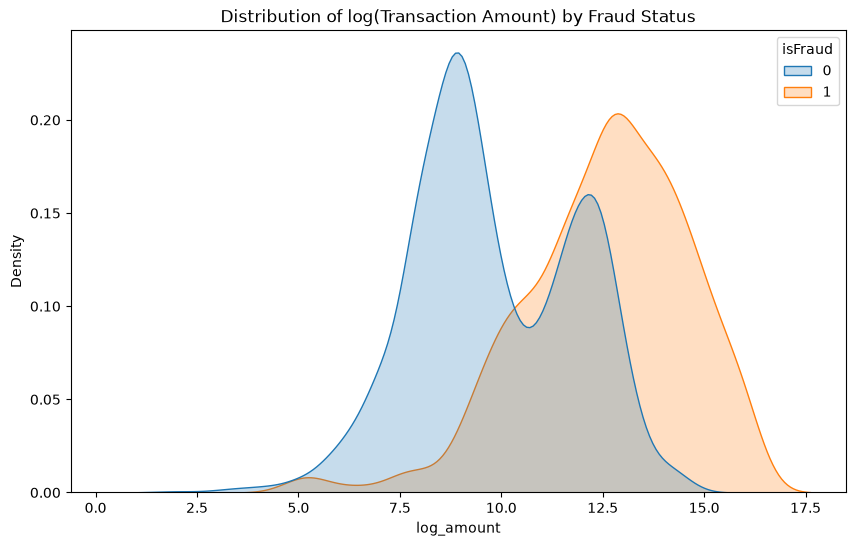

In [11]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="log_amount", hue="isFraud", fill=True, common_norm=False)
plt.title("Distribution of log(Transaction Amount) by Fraud Status")
plt.show()

### Correlation Heatmap

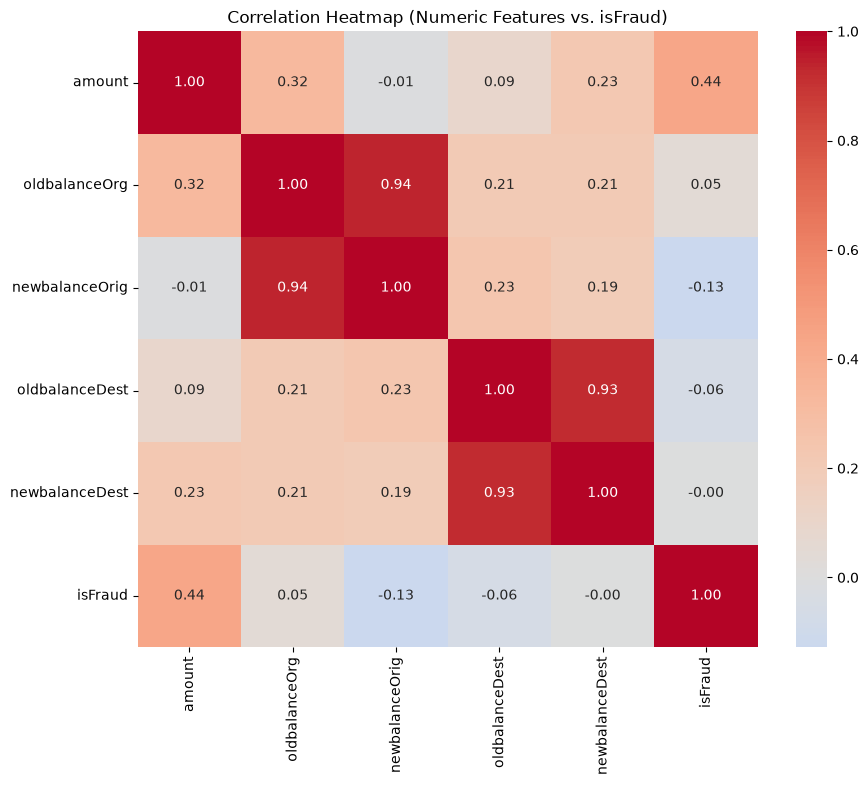

In [13]:
corr_columns = [c for c in num_columns if c not in ["step", "hourOfDay", "dayOfSimulation"]] + ["isFraud"]
plt.figure(figsize=(10, 8))
corr = df[corr_columns].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features vs. isFraud)")
plt.show()